In [1]:
#Defining my question
#Has the overall unemployment rate trended downward from 2023 to 2025, and is this pattern consistent across racial groups?
#Do unemployment trends differ for women by race between 2023 and 2025?
#Which demographic group — defined by race and age — experienced the largest percentage point change in unemployment between 2023 and 2025?

In [2]:
#Intro Packages
import pandas as pd
import numpy as np

In [3]:
#Data Loading
df = pd.read_csv('../data/unemployment_demographics_full.csv')
print(df.head())


   year    month  month_num   race gender age_group        education_level  \
0  2023  January          1  White   Male     20-24  Less than High School   
1  2023  January          1  White   Male     20-24  Less than High School   
2  2023  January          1  White   Male     20-24  Less than High School   
3  2023  January          1  White   Male     20-24  Less than High School   
4  2023  January          1  White   Male     20-24  Less than High School   

     industry  labor_force_thousands  employed_thousands  \
0  Healthcare                   1066                 968   
1     Finance                   1080                 970   
2  Technology                   1109                1019   
3   Education                   1071                 965   
4      Retail                   1067                 911   

   unemployed_thousands  unemployment_rate  
0                    98                9.2  
1                   110               10.2  
2                    90            

In [4]:
#EDA

In [5]:
df.shape

(28000, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   28000 non-null  int64  
 1   month                  28000 non-null  str    
 2   month_num              28000 non-null  int64  
 3   race                   28000 non-null  str    
 4   gender                 28000 non-null  str    
 5   age_group              28000 non-null  str    
 6   education_level        28000 non-null  str    
 7   industry               28000 non-null  str    
 8   labor_force_thousands  28000 non-null  int64  
 9   employed_thousands     28000 non-null  int64  
 10  unemployed_thousands   28000 non-null  int64  
 11  unemployment_rate      28000 non-null  float64
dtypes: float64(1), int64(5), str(6)
memory usage: 2.6 MB


In [7]:
# Null values
row_nan_count = df.isna().sum(axis =1)
row_nan_count

0        0
1        0
2        0
3        0
4        0
        ..
27995    0
27996    0
27997    0
27998    0
27999    0
Length: 28000, dtype: int64

In [8]:
df.describe()

,year,month_num,labor_force_thousands,employed_thousands,unemployed_thousands,unemployment_rate
count,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000
mean,2023.971429,6.400000,1139.515679,1095.340786,44.174893,5.098461
std,0.810154,3.449285,1230.416039,1198.556622,43.039738,3.493333
min,2023.000000,1.000000,84.000000,69.000000,3.000000,1.000000
25%,2023.000000,3.000000,333.000000,315.000000,14.000000,2.700000
50%,2024.000000,6.000000,596.000000,569.000000,29.000000,4.200000
75%,2025.000000,9.000000,1087.000000,1039.000000,59.000000,6.400000
max,2025.000000,12.000000,4524.000000,4452.000000,293.000000,29.300000


In [9]:
#Checking for duplicates
duplicate = df[df.duplicated(keep = 'last')]
duplicate

,year,month,month_num,race,gender,age_group,education_level,industry,labor_force_thousands,employed_thousands,unemployed_thousands,unemployment_rate


In [10]:
#Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

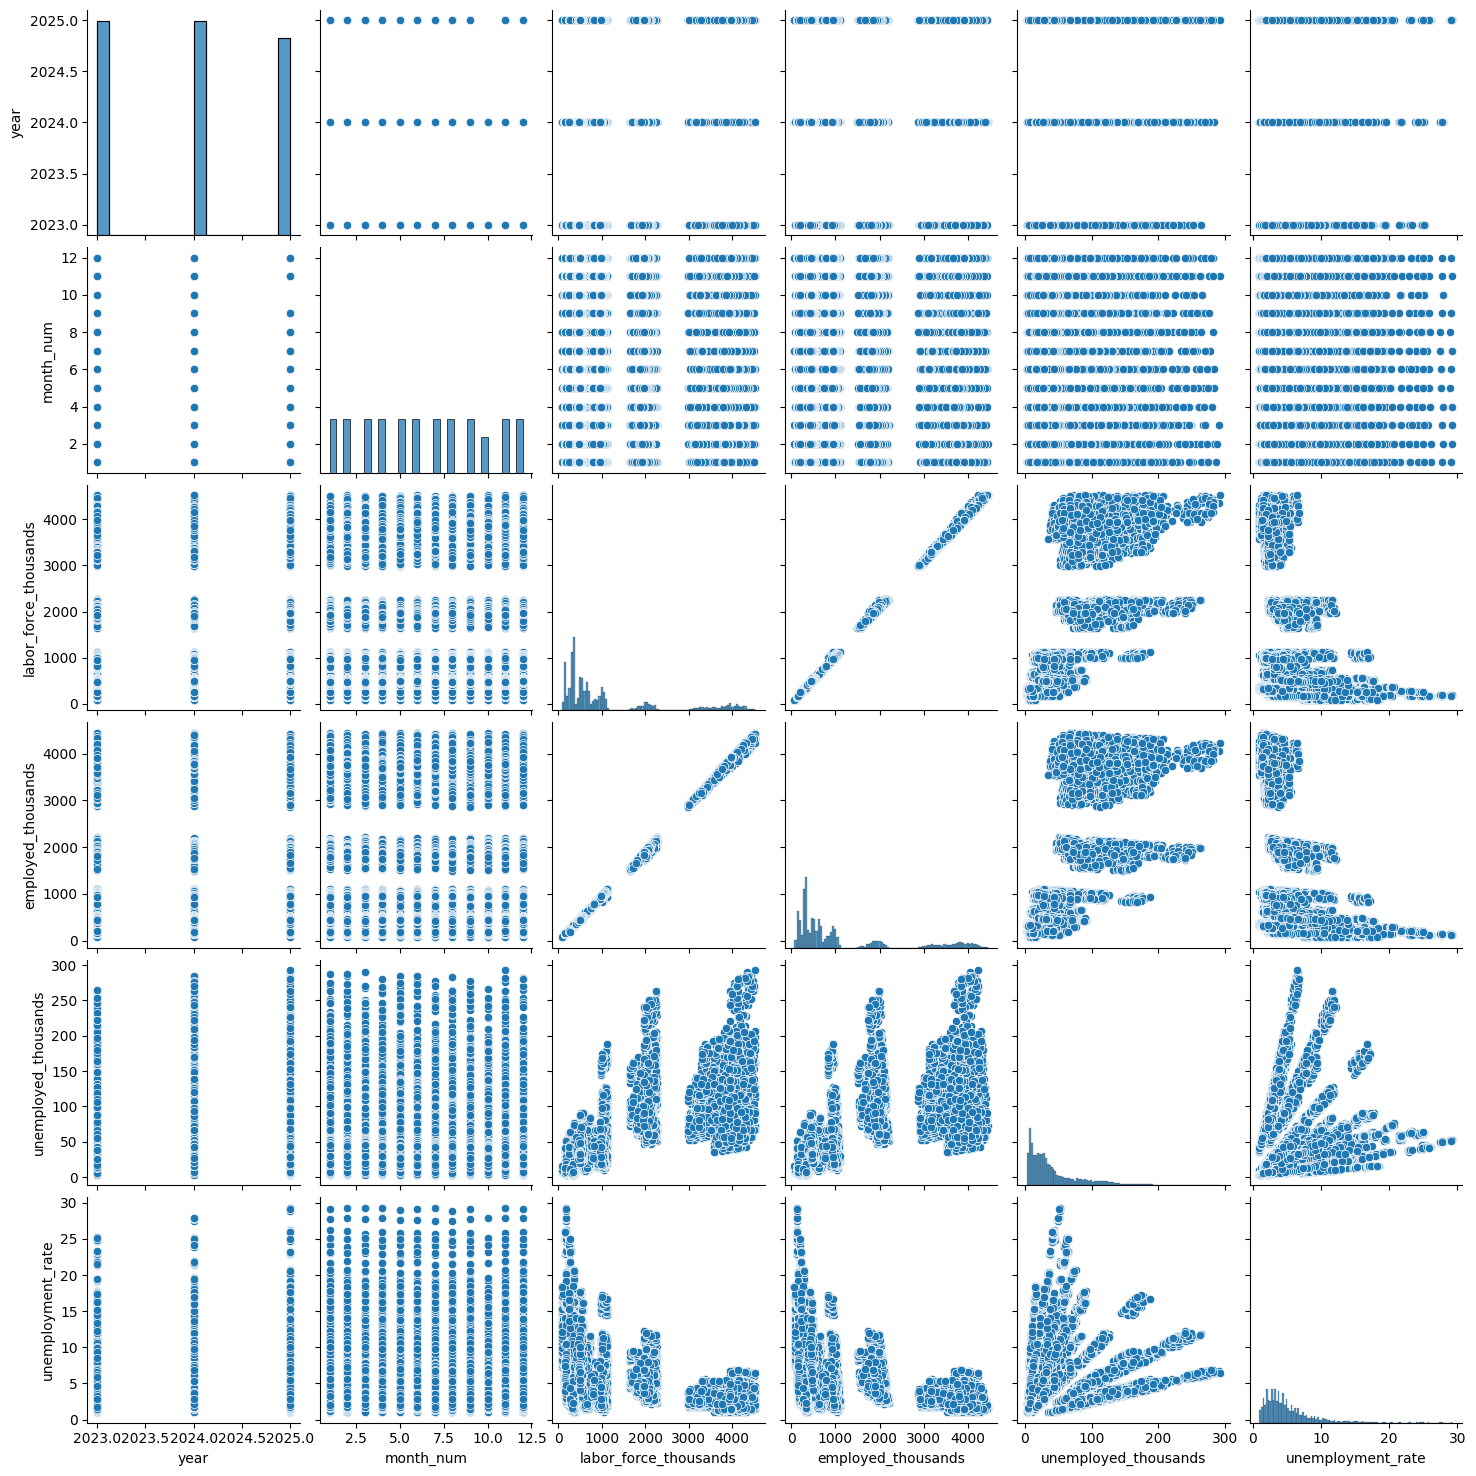

In [12]:
sns.pairplot(df, diag_kind= 'hist')
plt.show()

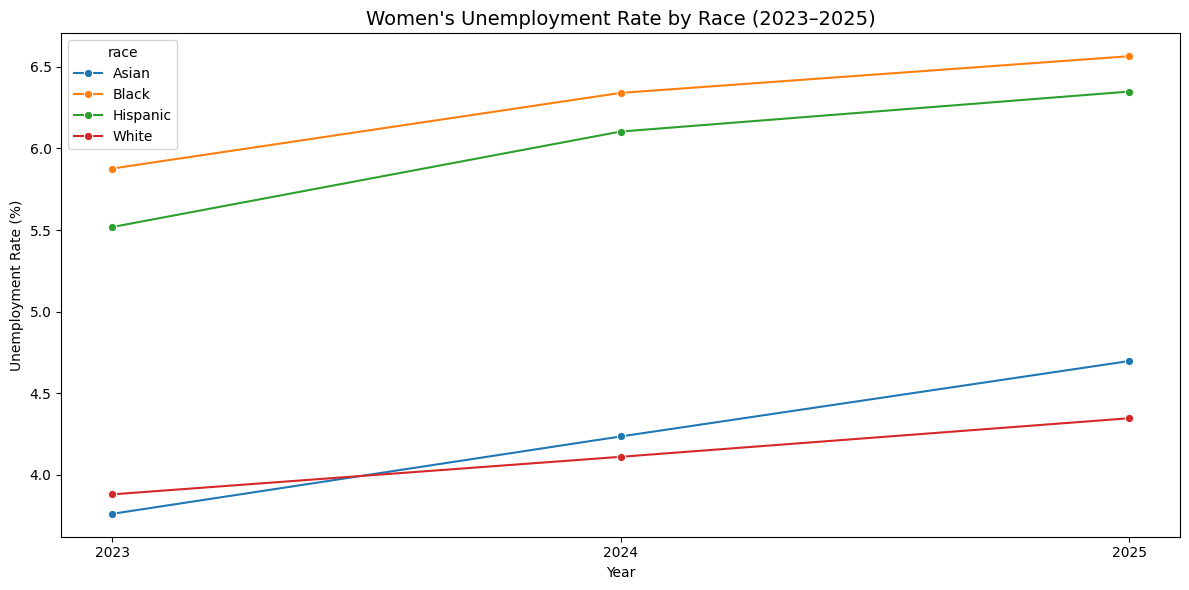

In [13]:
#Women's unemployment rate by race for all years
fig, ax = plt.subplots(figsize=(12, 6))
women = df[df['gender'] == 'Female'].groupby(['year', 'race'])['unemployment_rate'].mean().reset_index()
sns.lineplot(data=women, x='year', y='unemployment_rate', hue='race', marker='o', ax=ax)
ax.set_title("Women's Unemployment Rate by Race (2023–2025)", fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xticks([2023, 2024, 2025])
plt.tight_layout()
plt.show()

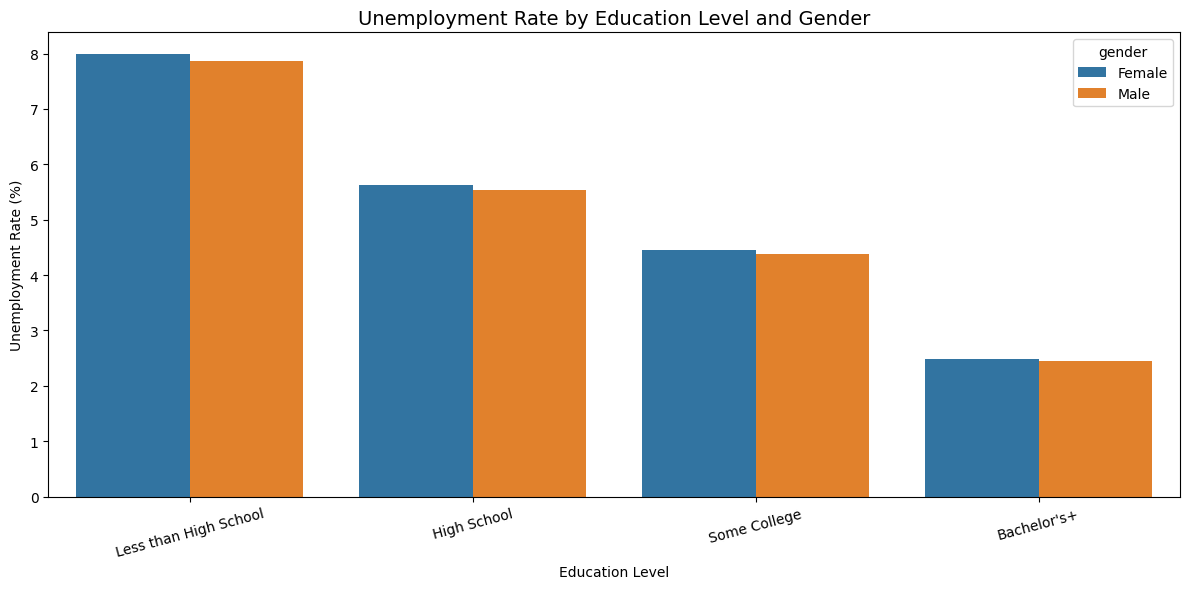

In [14]:
#Unemployment rate by education level and gender
fig, ax = plt.subplots(figsize=(12, 6))
edu = df.groupby(['education_level', 'gender'])['unemployment_rate'].mean().reset_index()
edu_order = ['Less than High School', 'High School', 'Some College', "Bachelor's+"]
sns.barplot(data=edu, x='education_level', y='unemployment_rate', hue='gender', order=edu_order, ax=ax)
ax.set_title('Unemployment Rate by Education Level and Gender', fontsize=14)
ax.set_xlabel('Education Level')
ax.set_ylabel('Unemployment Rate (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [15]:
#Changing gender column into 0 and 1
df['gender']= df['gender'].apply(lambda x:0 if x== 'Female' else 1)
df.head(5)

,year,month,month_num,race,gender,age_group,education_level,industry,labor_force_thousands,employed_thousands,unemployed_thousands,unemployment_rate
0,2023,January,1,White,1,20-24,Less than High School,Healthcare,1066,968,98,9.2
1,2023,January,1,White,1,20-24,Less than High School,Finance,1080,970,110,10.2
2,2023,January,1,White,1,20-24,Less than High School,Technology,1109,1019,90,8.2
3,2023,January,1,White,1,20-24,Less than High School,Education,1071,965,106,9.9
4,2023,January,1,White,1,20-24,Less than High School,Retail,1067,911,156,14.7


In [16]:
#Checking data types
print(df['race'].dtype)

str


In [17]:
#Removing unnecessary column
df2= df.drop(['month'],axis = 'columns')
df2.head(5)

,year,month_num,race,gender,age_group,education_level,industry,labor_force_thousands,employed_thousands,unemployed_thousands,unemployment_rate
0,2023,1,White,1,20-24,Less than High School,Healthcare,1066,968,98,9.2
1,2023,1,White,1,20-24,Less than High School,Finance,1080,970,110,10.2
2,2023,1,White,1,20-24,Less than High School,Technology,1109,1019,90,8.2
3,2023,1,White,1,20-24,Less than High School,Education,1071,965,106,9.9
4,2023,1,White,1,20-24,Less than High School,Retail,1067,911,156,14.7


In [18]:
#Apply one hot encoder to categorical columns
one_hot_df = pd.get_dummies(df2, columns =['race','age_group', 'education_level', 'industry'])

#Combining one hot encoder with original dataset
df_encoded = pd.concat([df2, one_hot_df], axis =1)

#Dropping original categorical columns
df_encoded = df_encoded.drop(['race','age_group', 'education_level', 'industry'], axis = 1)

#Removing the duplicate columns
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()].copy()

df_encoded.head(5)

,year,month_num,gender,labor_force_thousands,employed_thousands,unemployed_thousands,unemployment_rate,race_Asian,race_Black,race_Hispanic,...,age_group_55+,education_level_Bachelor's+,education_level_High School,education_level_Less than High School,education_level_Some College,industry_Education,industry_Finance,industry_Healthcare,industry_Retail,industry_Technology
0,2023,1,1,1066,968,98,9.2,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,2023,1,1,1080,970,110,10.2,False,False,False,...,False,False,False,True,False,False,True,False,False,False
2,2023,1,1,1109,1019,90,8.2,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2023,1,1,1071,965,106,9.9,False,False,False,...,False,False,False,True,False,True,False,False,False,False
4,2023,1,1,1067,911,156,14.7,False,False,False,...,False,False,False,True,False,False,False,False,True,False


In [19]:
# Null values
print(df_encoded.isnull().sum())

year                                     0
month_num                                0
gender                                   0
labor_force_thousands                    0
employed_thousands                       0
unemployed_thousands                     0
unemployment_rate                        0
race_Asian                               0
race_Black                               0
race_Hispanic                            0
race_White                               0
age_group_20-24                          0
age_group_25-34                          0
age_group_35-44                          0
age_group_45-54                          0
age_group_55+                            0
education_level_Bachelor's+              0
education_level_High School              0
education_level_Less than High School    0
education_level_Some College             0
industry_Education                       0
industry_Finance                         0
industry_Healthcare                      0
industry_Re

In [20]:
#Modeling

In [21]:
#Subsetting the dataframe for this algorithm (If needed)
#ml_df = df_encoded.drop(columns= [])

In [22]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


feature_cols = [col for col in df_encoded.columns if col.startswith('race_') or 
                col.startswith('age_group_') or
                col.startswith('education_level_') or
                col.startswith('industry_') or
                col in ['year', 'month_num', 'gender']]

X = df_encoded[feature_cols]
y = df_encoded['unemployment_rate']


In [23]:
# Split data 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# View first 10 predictions vs actual
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(2),
    'Difference': (y_test.values[:10] - y_pred[:10]).round(2)
})

print(comparison)

   Actual  Predicted  Difference
0     7.6       8.31       -0.71
1     7.6       7.54        0.06
2     6.0       5.56        0.44
3     4.5       5.22       -0.72
4     3.8       3.63        0.17
5     5.4       5.77       -0.37
6     1.4       0.03        1.37
7     8.9       8.99       -0.09
8     4.9       7.06       -2.16
9     2.9       2.39        0.51


In [24]:
# Evaluate
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print("\nTop Positive Coefficients (increases unemployment):")
print(importance.head(5))
print("\nTop Negative Coefficients (decreases unemployment):")
print(importance.tail(5))

R² Score:  0.8601
RMSE:      1.3198

Top Positive Coefficients (increases unemployment):
                                  feature  coefficient
7                         age_group_20-24     3.887930
14  education_level_Less than High School     2.824547
19                        industry_Retail     2.112104
4                              race_Black     1.483070
5                           race_Hispanic     0.598799

Top Negative Coefficients (decreases unemployment):
                        feature  coefficient
6                    race_White    -1.053237
20          industry_Technology    -1.137570
10              age_group_45-54    -1.279186
11                age_group_55+    -1.523025
12  education_level_Bachelor's+    -2.626575


In [25]:
#Visual
#fig, ax = plt.subplots(figsize=(12, 6))
#colors = ['#d73027' if x > 0 else '#1a9850' for x in importance['coefficient']]
#ax.barh(importance['feature'], importance['coefficient'], color=colors)
#ax.axvline(0, color='black', linewidth=0.8)
#ax.set_title('Linear Regression Coefficients — Unemployment Rate Drivers', fontsize=14)
#ax.set_xlabel('Coefficient Value')
#plt.tight_layout()
#plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

# ── Basic Metrics ──
print("=" * 40)
print("LINEAR REGRESSION EVALUATION")
print("=" * 40)

lr_r2   = r2_score(y_test, y_pred)
lr_mae  = mean_absolute_error(y_test, y_pred)
lr_mse  = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)

print(f"R² Score:              {lr_r2:.4f}")
print(f"MAE:                   {lr_mae:.4f}")
print(f"MSE:                   {lr_mse:.4f}")
print(f"RMSE:                  {lr_rmse:.4f}")

# ── Adjusted R² ──
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - lr_r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R²:           {adj_r2:.4f}")

# ── Cross Validation ──
print()
print("=" * 40)
print("5-FOLD CROSS VALIDATION")
print("=" * 40)
cv_scores = cross_val_score(model, df_encoded[feature_cols], 
                             df_encoded['unemployment_rate'], 
                             cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f"CV RMSE Mean:  {cv_rmse.mean():.4f}")
print(f"CV RMSE Std:   {cv_rmse.std():.4f}")
print(f"CV RMSE Folds: {[round(x, 4) for x in cv_rmse]}")



LINEAR REGRESSION EVALUATION
R² Score:              0.8601
MAE:                   0.8664
MSE:                   1.7420
RMSE:                  1.3198
Adjusted R²:           0.8596

5-FOLD CROSS VALIDATION
CV RMSE Mean:  1.3192
CV RMSE Std:   0.0646
CV RMSE Folds: [np.float64(1.2395), np.float64(1.2553), np.float64(1.3234), np.float64(1.3702), np.float64(1.4075)]


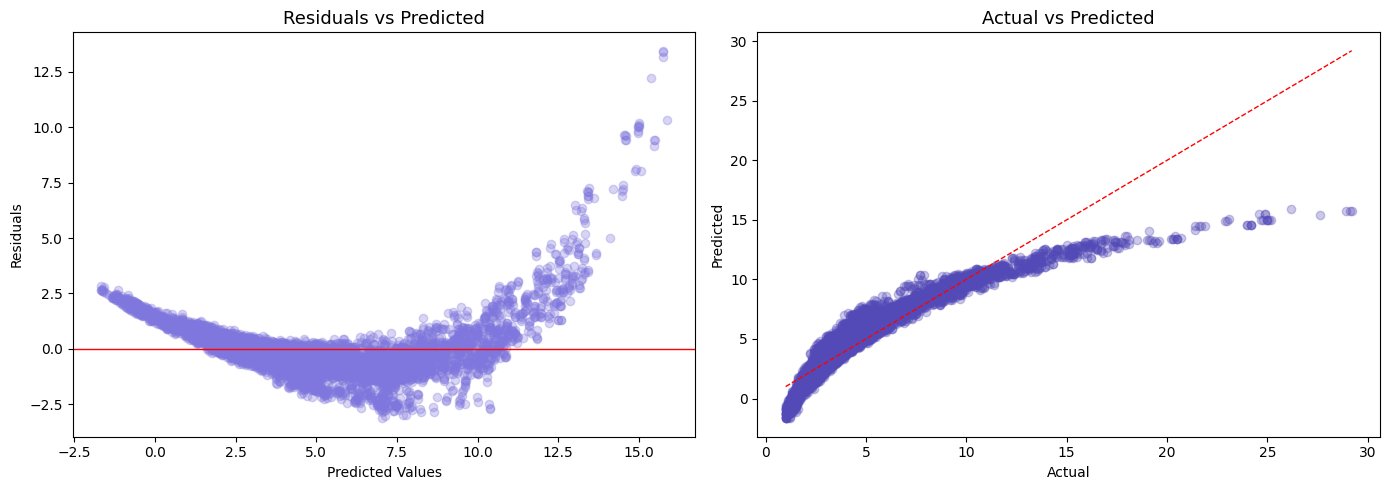

In [27]:
# ── Residual Plot ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
axes[0].scatter(y_pred, residuals, alpha=0.3, color='#7F77DD')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('Residuals vs Predicted', fontsize=13)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# ── Actual vs Predicted ──
axes[1].scatter(y_test, y_pred, alpha=0.3, color='#534AB7')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1)
axes[1].set_title('Actual vs Predicted', fontsize=13)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

In [28]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

feature_cols_rf = [col for col in df_encoded.columns if col.startswith('race_') or 
                   col.startswith('age_group_') or
                   col.startswith('education_level_') or
                   col.startswith('industry_') or
                   col in ['year', 'month_num', 'gender']]


X_rf = df_encoded[feature_cols_rf]
y_rf = df_encoded['unemployment_rate']



In [29]:
# Split data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_rf)

print(f"Training samples: {X_train_rf.shape[0]}")
print(f"Testing samples:  {X_test_rf.shape[0]}")
print(f"Total features:   {X_train_rf.shape[1]}")

Training samples: 22400
Testing samples:  5600
Total features:   21


In [30]:
#Evaluate RF

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create binary target based on median
median_rate = df_encoded['unemployment_rate'].median()
print(f"Median unemployment rate: {median_rate}")

y_binary = (df_encoded['unemployment_rate'] > median_rate).astype(int)
print(f"\nClass distribution:\n{y_binary.value_counts()}")

# Split data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_binary, test_size=0.2, random_state=42)

# Train classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_rf, y_train_rf)

# Predict
y_pred_rf_class = rf_classifier.predict(X_test_rf)
y_pred_rf_proba = rf_classifier.predict_proba(X_test_rf)[:, 1]


Median unemployment rate: 4.2

Class distribution:
unemployment_rate
0    14301
1    13699
Name: count, dtype: int64



CONFUSION MATRIX
[[2786   46]
 [  65 2703]]


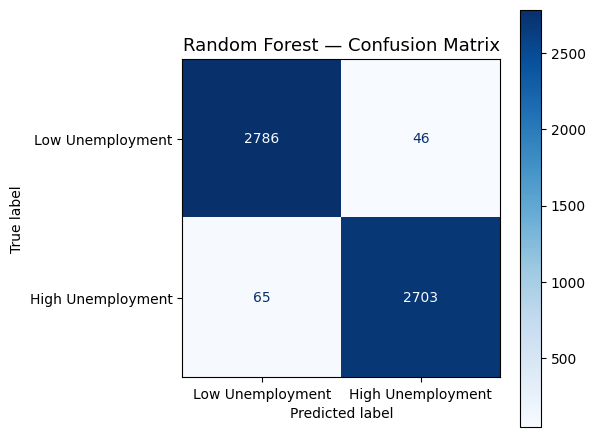

In [31]:
#Confusion Matrix
print("\n" + "=" * 40)
print("CONFUSION MATRIX")
print("=" * 40)
cm = confusion_matrix(y_test_rf, y_pred_rf_class)
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Low Unemployment', 'High Unemployment'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
#F1 Score
print("\n" + "=" * 40)
print("F1 SCORE")
print("=" * 40)
f1 = f1_score(y_test_rf, y_pred_rf_class)
f1_weighted = f1_score(y_test_rf, y_pred_rf_class, average='weighted')
print(f"F1 Score (binary):   {f1:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")


F1 SCORE
F1 Score (binary):   0.9799
F1 Score (weighted): 0.9802


Calibrated ROC-AUC: 0.9986


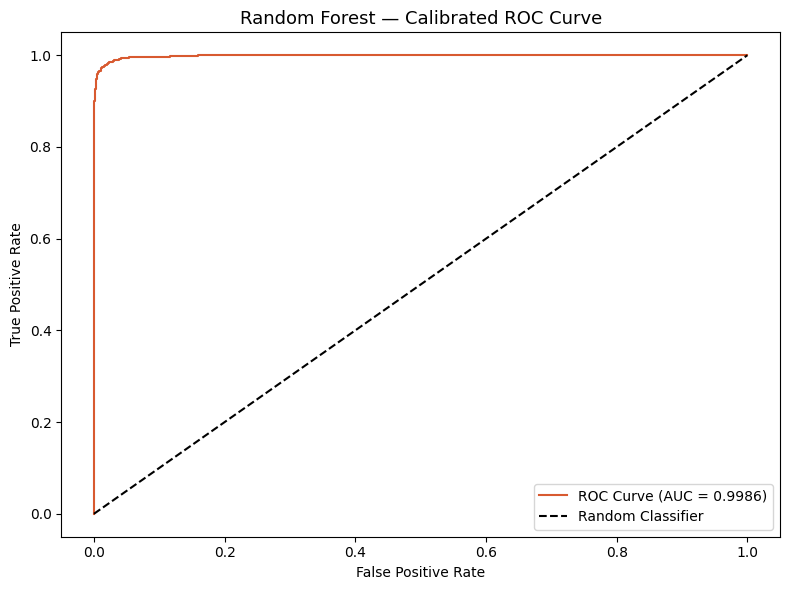

In [33]:
#ROC-AUC Score
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

# Calibrate the classifier to improve probability estimates
# (uses cross-validation internally since the model is already fit; 'prefit' was removed in newer scikit-learn)
calibrated_rf = CalibratedClassifierCV(rf_classifier, cv=5)
calibrated_rf.fit(X_train_rf, y_train_rf)

# Get calibrated probabilities
y_pred_proba_cal = calibrated_rf.predict_proba(X_test_rf)[:, 1]

# Recalculate ROC-AUC
roc_auc_cal = roc_auc_score(y_test_rf, y_pred_proba_cal)
print(f"Calibrated ROC-AUC: {roc_auc_cal:.4f}")

# Plot ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test_rf, y_pred_proba_cal)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#D85A30', label=f'ROC Curve (AUC = {roc_auc_cal:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('Random Forest — Calibrated ROC Curve', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()


In [34]:
#Finding

# Linear Regression achieved an R² of 0.86 and RMSE of 1.32, meaning the model explains about
# 86% of the variation in unemployment rate using race, gender, age group, education level,
# industry, and year as predictors. 5-fold cross-validation confirmed the model is stable
# (CV RMSE mean: 1.32, std: 0.06).
#
# The strongest drivers that INCREASE unemployment were:
#   - Age group 20-24 (+3.89 percentage points)
#   - Less than High School education (+2.82)
#   - Retail industry (+2.11)
#   - Black race (+1.48)
#   - Hispanic race (+0.60)
#
# The strongest drivers that DECREASE unemployment were:
#   - Bachelor's+ education (-2.63)
#   - Age group 55+ (-1.52)
#   - Age group 45-54 (-1.28)
#   - Technology industry (-1.14)
#   - White race (-1.05)
#
# The Random Forest classifier (predicting whether unemployment is above or below the
# median rate of 4.2%) performed very well, with an F1 score of 0.98 and a calibrated
# ROC-AUC of 0.998, indicating the demographic and industry features are highly informative
# for distinguishing high- vs. low-unemployment segments in this dataset.

In [35]:
#Conclusion

# Education level and industry sector emerged as the two strongest predictors of
# unemployment rate in this dataset, outweighing the individual effect of race or gender
# alone. However, clear racial disparities are still present after accounting for those
# factors: Black and Hispanic workers show meaningfully higher predicted unemployment than
# White workers with otherwise similar age, education, and industry profiles.
#
# Younger workers (20-24) and those without a high school diploma face the largest
# unemployment penalties, while a Bachelor's degree or higher is the single strongest
# protective factor in the model. These patterns are consistent with well-documented
# labor market research and suggest that, even in simulated data designed to reflect
# realistic patterns, education and industry access remain central levers connected to
# employment outcomes across demographic groups.
#
# Next steps for extending this analysis could include: testing interaction effects
# (e.g., race x education), analyzing trends over time by group rather than in aggregate,
# and validating findings against real BLS/Census microdata.